# ROI Pooling

In [80]:
# Implement a ROI Pooling operator. Given the following variables:
# "input" --> (N, C, H, W) tensor
# "boxes" --> list of bounding box coordinates to perform ROI
#       (L, 4) tensors --> boxes[i] is the i-th element o the batch, contain L coordinates (y1, x1, y2, x2)
# "output_size" --> number of cells over which pooling is performed (height, width)

# "output" --> (N, L, C, output_size[0], output_size[1])

In [81]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt

import math

#### Setup

In [82]:
# Set-up code
n = random.randint(1, 3)
C = random.randint(10, 20)
H = random.randint(5, 10)
W = random.randint(5, 10)
# con che criterio ha scelto oH e oW? dimensione minima delle roi
oH = random.randint(2, 4)
oW = random.randint(2, 4)
L = random.randint(2, 6)
input = torch.rand(n, C, H, W)
boxes = [torch.zeros(L, 4) for _ in range(n)]
for i in range(n):
  boxes[i][:, 0] = torch.rand(L) * (H-oH)       # y
  boxes[i][:, 1] = torch.rand(L) * (W-oW)       # x
  boxes[i][:, 2] = oH + torch.rand(L) * (H-oH)  # w
  boxes[i][:, 3] = oW + torch.rand(L) * (W-oW)  # h

  boxes[i][:,2:] += boxes[i][:,:2]
  boxes[i][:,2] = torch.clamp(boxes[i][:,2], max=H-1)
  boxes[i][:,3] = torch.clamp(boxes[i][:,3], max=W-1)
output_size = (oH, oW)

In [83]:
print("input shape: (n, C, H, W) -->", input.shape, '\n')

# L = 3 è il numero di righe cioè il numero di box per ogni elemento del batch, 4 è il numero di coordinate (y1, x1, y2, x2)
print("boxes shape: (L, 4)       -->", boxes[0].shape, '\n')

print("output_size: (oH, oW)     -->", output_size, '\n')

input shape: (n, C, H, W) --> torch.Size([3, 18, 8, 10]) 

boxes shape: (L, 4)       --> torch.Size([3, 4]) 

output_size: (oH, oW)     --> (4, 3) 



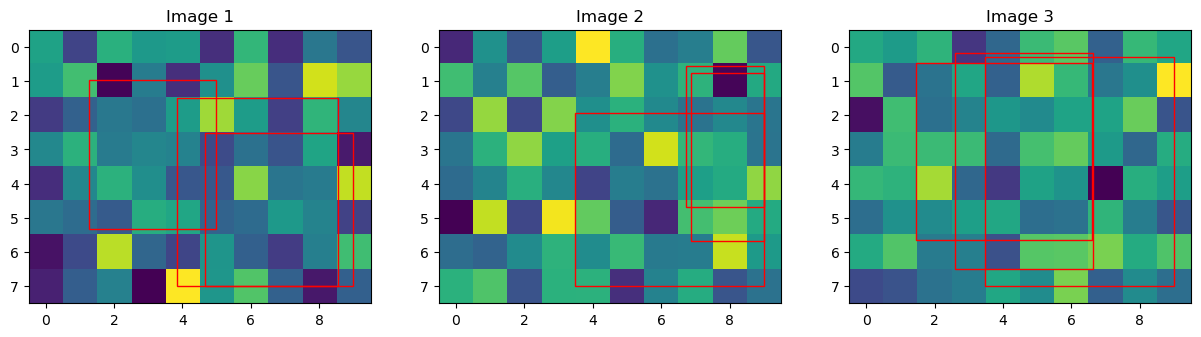

In [84]:
# VISUALIZATION OF INPUT IMAGE AND BOXES

fig, axs = plt.subplots(1, n, figsize=(15, 5))

if n == 1:
    axs = [axs]

for i in range(n):
    img = input[i].mean(dim=0) 
    axs[i].imshow(img.numpy())

    for j in range(L):
        y1, x1, y2, x2 = boxes[i][j]
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                             edgecolor='red', facecolor='none')
        axs[i].add_patch(rect)

    axs[i].set_title(f'Image {i+1}')

In [85]:
# L è il numero di box per ogni elemento del batch (n), quindi il numero di box per immagine è lo stesso
# ma ogni immagine ha box diversi perché le righe (cioè le coordinate), sono diverse

# !!! "boxes" è una lista di n matrici ognuna contenente L box di 4 coordinate (2 punti) !!!

In [86]:
boxes

[tensor([[1.4859, 3.8291, 7.0000, 8.5530],
         [2.5077, 4.6543, 7.0000, 9.0000],
         [0.9776, 1.2789, 5.3411, 4.9833]]),
 tensor([[1.9283, 3.4910, 7.0000, 9.0000],
         [0.7769, 6.8597, 5.6704, 9.0000],
         [0.5709, 6.7395, 4.6730, 9.0000]]),
 tensor([[0.4699, 1.4474, 5.6506, 6.6110],
         [0.1944, 2.6077, 6.4962, 6.6359],
         [0.3113, 3.4613, 7.0000, 9.0000]])]

In [87]:
# Logica del ROI Pooling:
#
# Il ROI Pooling è un modo per trasformare regioni di dimensioni diverse in feature map a dimensione fissa:
# Feature Map (C, H, W) e tante "bounding box" (ROI) con dimensioni diverse --> ma le reti vogliono l'input sempre nella stessa dimansione
# Il ROI Pooling trasforma ogni box in una griglia fissa --> si ritaglia il bounding box in una griglia fissa (oH, oW) --> in ogni cella della griglia si fa Max Pooling!!
# Il ROI Pooling arrotonda le coordinate --> perde precisione
#
#   Vincolo implicito: oH < y2-y1+1 ed oW < x2-x1+1 
#
#   0) Mappare il bounding box sulla feature-map convoluzionale
#   1) Estrarre ogni ROI da ogni immagine (definita dalle coordinate in boxes) e di dimensione (h_roi, w_roi)
#   2) Dividerla in una griglia fissa (oH x oW) con bin di dimensione (h_roi/oH, w_roi/oW) --> possono esserci bin irregolari
#   3) Quantizzare i bordi dei bin --> math.floor e math.ceil
#   4) Fare Max Pooling dentro ogni bin ed inserire in output --> dimensione finale (C, oH, oW)

#### Single Steps Logic

In [88]:
# example: extraction of coordinates
y1, x1, y2, x2 = boxes[0][0]
print(f"y1: {y1}\nx1: {x1}\ny2: {y2}\nx2: {x2}")

y1: 1.4859273433685303
x1: 3.8290820121765137
y2: 7.0
x2: 8.553020477294922


In [89]:
# SNAPPING each box TO THE GRID --> nearest integer values --> .round() function
y1_snap = torch.round(y1).int()
x1_snap = torch.round(x1).int()
y2_snap = torch.round(y2).int()
x2_snap = torch.round(x2).int()

print(f"y1_snapped: {y1_snap}\nx1_snapped: {x1_snap}\ny2_snapped: {y2_snap}\nx2_snapped: {x2_snap}")

y1_snapped: 1
x1_snapped: 4
y2_snapped: 7
x2_snapped: 9


In [90]:
# VISUALIZATION OF ORIGINAL AND SNAPPED BOX

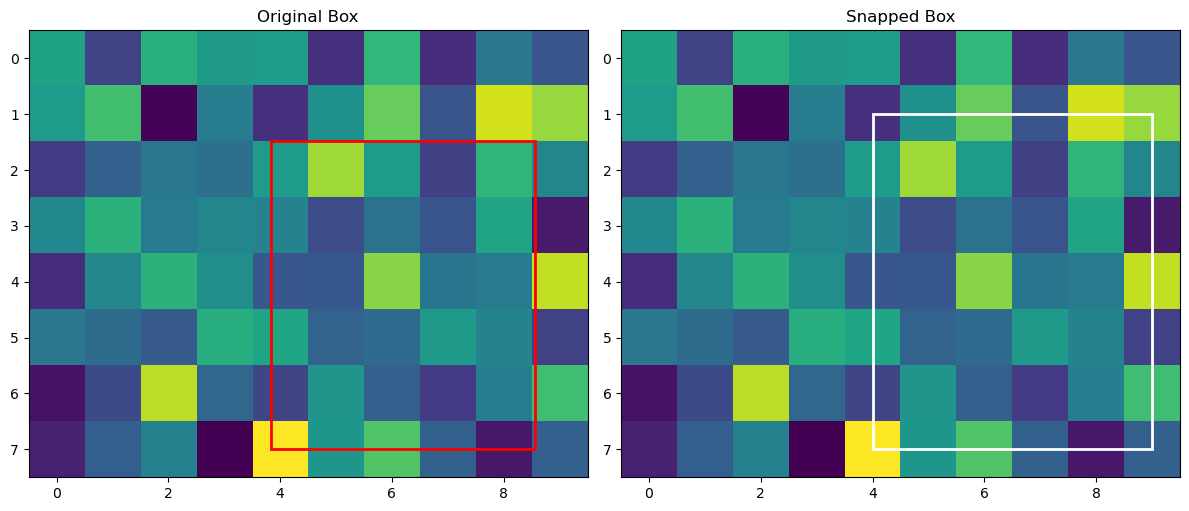

In [91]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))

img = input[0].mean(dim=0)

# -----------------
# Box originale
# -----------------
axs[0].imshow(img.numpy())

y1, x1, y2, x2 = boxes[0][0]

rect = plt.Rectangle(
    (x1, y1),
    x2 - x1,
    y2 - y1,
    edgecolor='red',
    facecolor='none',
    linewidth=2
)

axs[0].add_patch(rect)
axs[0].set_title('Original Box')


# -----------------
# Box snapped
# -----------------
axs[1].imshow(img.numpy())

y1, x1, y2, x2 = (
    y1_snap.float(),
    x1_snap.float(),
    y2_snap.float(),
    x2_snap.float()
)

rect = plt.Rectangle(
    (x1, y1),
    x2 - x1,
    y2 - y1,
    edgecolor='white',
    facecolor='none',
    linewidth=2
)

axs[1].add_patch(rect)
axs[1].set_title('Snapped Box')

plt.tight_layout()
plt.show()

In [92]:
# DIVIDING each box in a FIXED oH x oW GRID
i = torch.arange(0, oH, dtype=torch.int)
j = torch.arange(0, oW, dtype=torch.int)
print(i, '\n', j, '\n')

h_roi = y2_snap - y1_snap + 1
w_roi = x2_snap - x1_snap + 1

# math on the slides
y_start = torch.floor(y1_snap + i*(h_roi/oH)).int()
x_start = torch.floor(x1_snap + j*(w_roi/oW)).int()
y_end = torch.ceil(y1_snap + (i+1)*(h_roi/oH)).int()
x_end = torch.ceil(x1_snap + (j+1)*(w_roi/oW)).int()
print(f"y_start: {y_start}\ny_end: {y_end}\n\nx_start: {x_start}\nx_end: {x_end}")

# logic:
# y_start[i] = row where bin "i" begins
# y_end[i] = row where bin "i" ends
# x_start[j] = column where bin "j" begins
# x_end[j] = column ehere bin "j" ends
#
# bin (i, j) is:
# feature[:, y_start[i]:y_end[i], x_start[j]:x_end[j]]

tensor([0, 1, 2, 3], dtype=torch.int32) 
 tensor([0, 1, 2], dtype=torch.int32) 

y_start: tensor([1, 2, 4, 6], dtype=torch.int32)
y_end: tensor([3, 5, 7, 8], dtype=torch.int32)

x_start: tensor([4, 6, 8], dtype=torch.int32)
x_end: tensor([ 6,  8, 10], dtype=torch.int32)


In [93]:
# VISUALIZATION OF THE GRID IN THE ROI

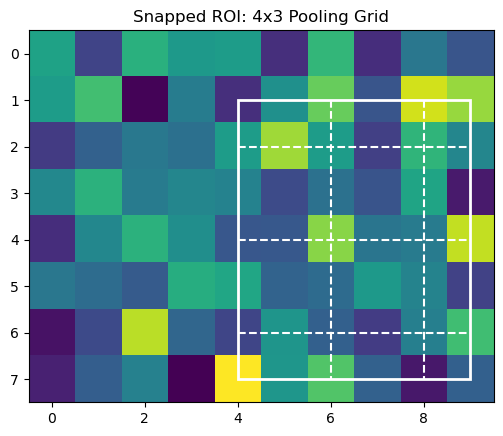

In [94]:
fig, ax = plt.subplots(figsize=(6,6))

img = input[0].mean(dim=0)
ax.imshow(img.numpy())

# -----------------
# ROI snapped esterna
# -----------------
y1, x1, y2, x2 = (
    y1_snap.float(),
    x1_snap.float(),
    y2_snap.float(),
    x2_snap.float()
)

rect = plt.Rectangle(
    (x1, y1),
    x2 - x1,
    y2 - y1,
    edgecolor='white',
    facecolor='none',
    linewidth=2
)

ax.add_patch(rect)

# -----------------
# Griglia interna ROI pooling
# -----------------

# Linee verticali interne (divisioni tra colonne)
for k in range(1, oW):
    x = x_start[k].item()
    ax.plot(
        [x, x],
        [y1, y2],
        linestyle='--',
        color='white'
    )

# Linee orizzontali interne (divisioni tra righe)
for k in range(1, oH):
    y = y_start[k].item()
    ax.plot(
        [x1, x2],
        [y, y],
        linestyle='--',
        color='white'
    )

ax.set_title(f'Snapped ROI: {oH}x{oW} Pooling Grid')

plt.show()

In [95]:
# initialization output tensor
output = torch.zeros((n, L, C, oH, oW), dtype=torch.float32)
print(f"Output shape (n, L, C, oH, oW): {output.shape}")

Output shape (n, L, C, oH, oW): torch.Size([3, 3, 18, 4, 3])


In [96]:
# MAX POOLING in each cell
for i in range(oH):
    for j in range(oW):
        cell = input[0, :, y_start[i]:y_end[i], x_start[j]:x_end[j]].amax(dim=(1, 2))
        print(f"Cell ({i}, {j})\n\tchannels: {cell.shape}\n\tvalues: {cell}")
        output[0, 0, :, i, j] = cell

Cell (0, 0)
	channels: torch.Size([18])
	values: tensor([0.9331, 0.6842, 0.7828, 0.8586, 0.8828, 0.9218, 0.7553, 0.7864, 0.6438,
        0.5711, 0.7369, 0.8701, 0.9608, 0.6072, 0.9141, 0.9974, 0.9655, 0.7813])
Cell (0, 1)
	channels: torch.Size([18])
	values: tensor([0.5351, 0.9356, 0.8435, 0.8379, 0.7697, 0.8610, 0.9207, 0.5073, 0.9103,
        0.9993, 0.7399, 0.6841, 0.9215, 0.7646, 0.7140, 0.9780, 0.7706, 0.9616])
Cell (0, 2)
	channels: torch.Size([18])
	values: tensor([0.9225, 0.9694, 0.6407, 0.6619, 0.9180, 0.8999, 0.7310, 0.7811, 0.7287,
        0.8419, 0.8333, 0.9248, 0.9964, 0.8438, 0.9292, 0.6966, 0.6324, 0.9981])
Cell (1, 0)
	channels: torch.Size([18])
	values: tensor([0.9331, 0.8852, 0.7766, 0.9759, 0.7657, 0.8216, 0.7553, 0.8123, 0.7966,
        0.3121, 0.7369, 0.8701, 0.8984, 0.6843, 0.9268, 0.9974, 0.9655, 0.9930])
Cell (1, 1)
	channels: torch.Size([18])
	values: tensor([0.6483, 0.9688, 0.8281, 0.8754, 0.7697, 0.8093, 0.9857, 0.9637, 0.9103,
        0.9993, 0.9713, 0.9765,

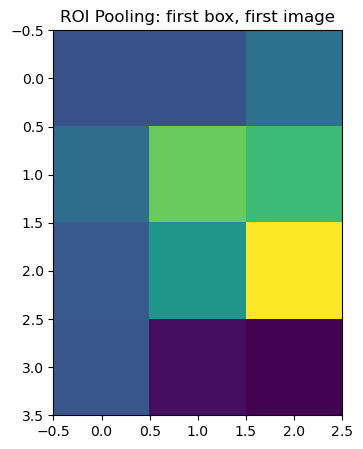

In [97]:
# VISUALIZING OUTPUT
output_img = output[0, 0].mean(dim=0)
plt.figure(figsize=(5, 5))
plt.imshow(output_img.numpy())
plt.title('ROI Pooling: first box, first image')
plt.show()

#### ROI Function

In [98]:
def roi_pooling(input, boxes, output_size):
    n, C, H, W = input.shape
    L = boxes[0].shape[0]
    oH, oW = output_size
    
    out = torch.zeros((n, L, C, oH, oW), dtype=torch.float32)

    
    for image in range(n):
        for r in range(L):
            y1, x1, y2, x2 = boxes[image][r]
            
            # SNAP
            y1_snap = torch.round(y1).int()
            x1_snap = torch.round(x1).int()
            y2_snap = torch.round(y2).int()
            x2_snap = torch.round(x2).int()
            
            # GRID
            i = torch.arange(0, oH, dtype=torch.float32)
            j = torch.arange(0, oW, dtype=torch.float32)
            
            h_roi = y2_snap - y1_snap + 1
            w_roi = x2_snap - x1_snap + 1
            
            y_start = torch.floor(y1_snap + i*(h_roi/oH)).int()
            x_start = torch.floor(x1_snap + j*(w_roi/oW)).int()
            y_end = torch.ceil(y1_snap + (i+1)*(h_roi/oH)).int()
            x_end = torch.ceil(x1_snap + (j+1)*(w_roi/oW)).int()
            
            # MAX POOLING
            for h in range(oH):
                for w in range(oW):
                    cell = input[image, :, y_start[h]:y_end[h], x_start[w]:x_end[w]].amax(dim=(1, 2))
                    out[image, r, :, h, w] = cell   
        
    return out
    

In [99]:
output = roi_pooling(input, boxes, output_size)
print(f"Output shape: (n, L, C, oH, oW) --> {output.shape}")

Output shape: (n, L, C, oH, oW) --> torch.Size([3, 3, 18, 4, 3])


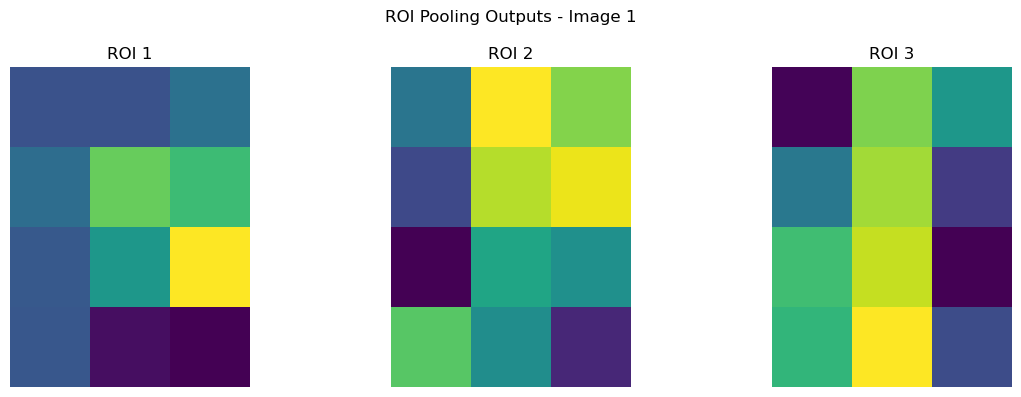

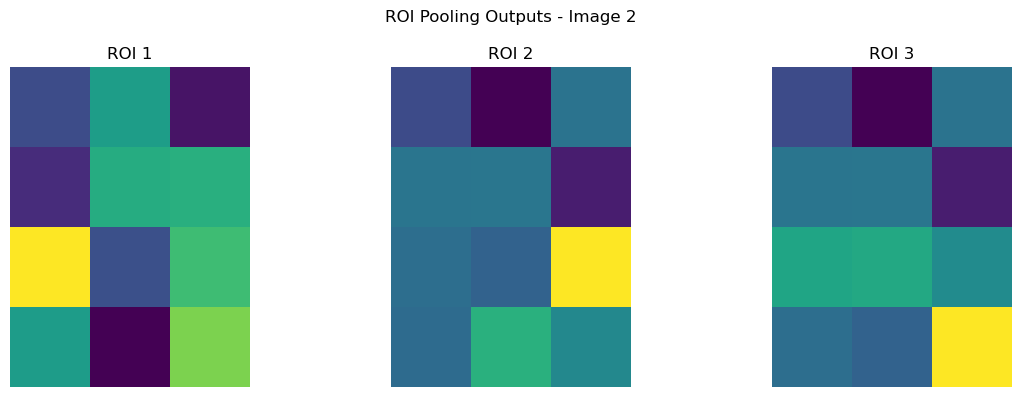

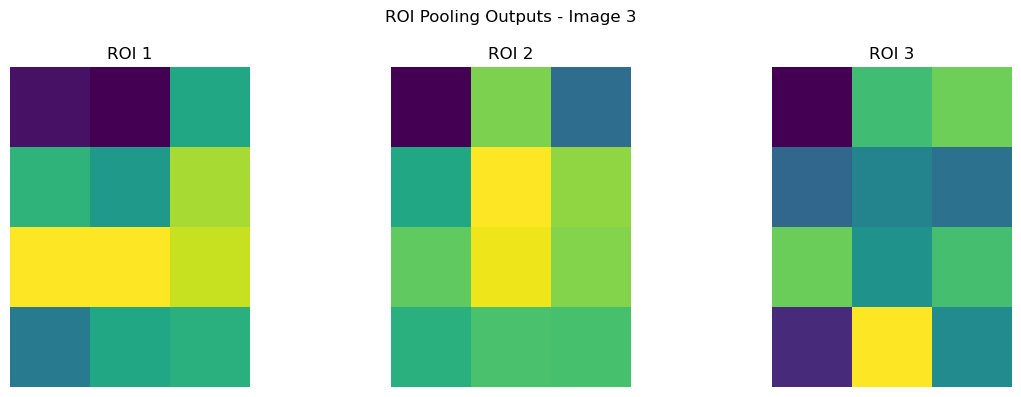

In [100]:
# VISUALIZING ALL ROI 
import math

for image in range(n):

    cols = min(4, L)  # numero di colonne nella griglia
    rows = math.ceil(L / cols)

    fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axs = axs.flatten() if L > 1 else [axs]

    for r in range(L):

        output_img = output[image, r].mean(dim=0)

        axs[r].imshow(output_img.numpy())
        axs[r].set_title(f'ROI {r+1}')
        axs[r].axis('off')

    # spegni eventuali subplot vuoti
    for k in range(L, len(axs)):
        axs[k].axis('off')

    fig.suptitle(f'ROI Pooling Outputs - Image {image+1}')
    plt.tight_layout()
    plt.show()